In [28]:
import pennylane as qml
import torch
import matplotlib.pyplot as plt
import math

%reload_ext autoreload
%autoreload 2

import utiles as ut

from QDDM import QuantumDiffusion, QuantumDenoising

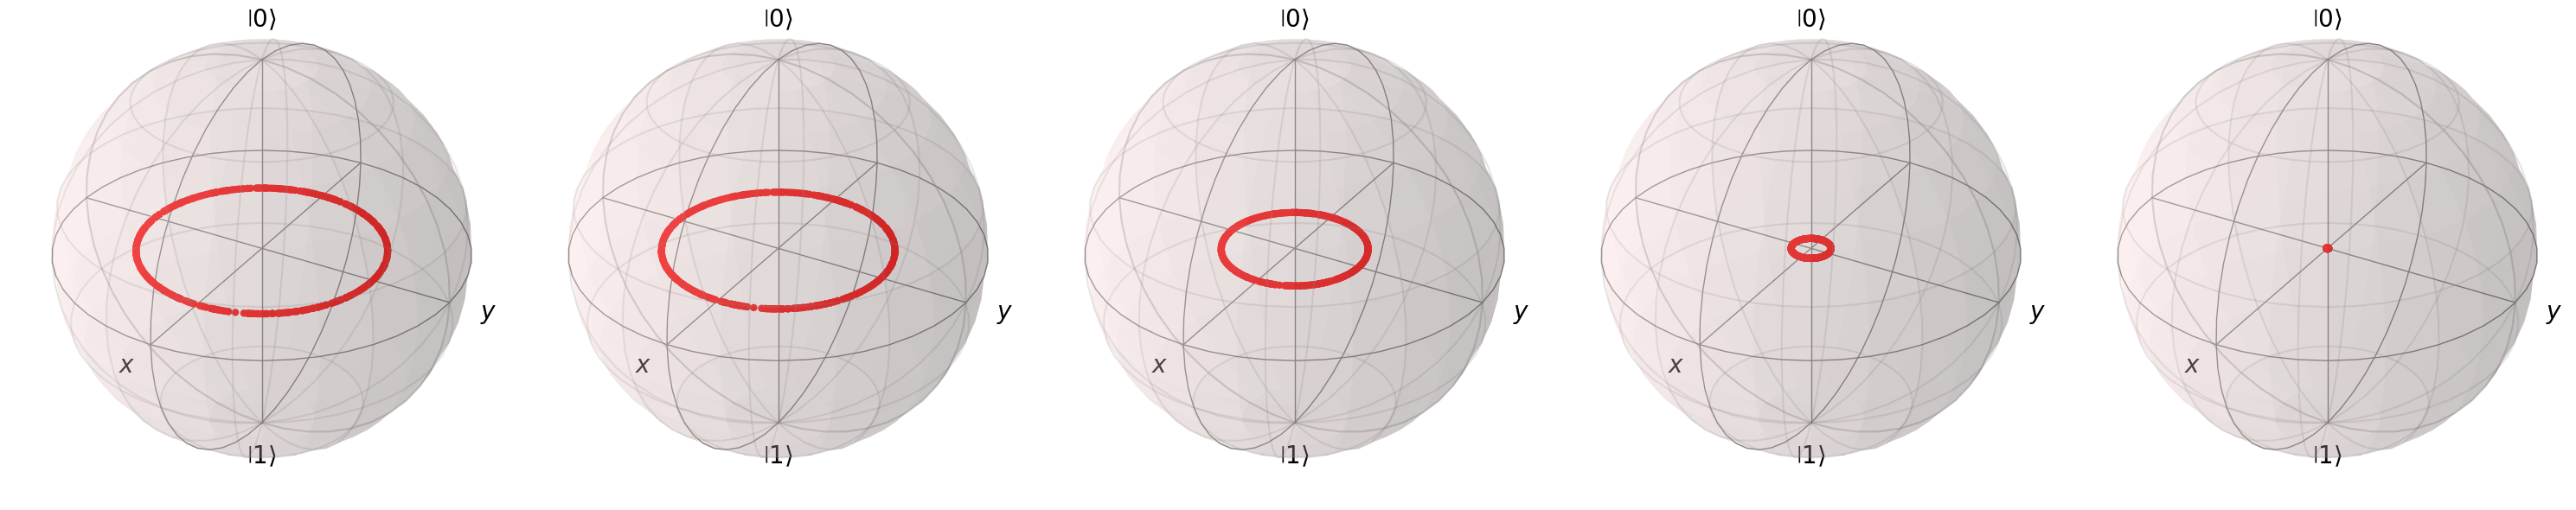

In [22]:
#DEPOLARIZING
n=1
T=20 
N=500

#anillo
probs,ensemble=ut.generate_mix_ring(N,0.3,0)
p_t=0.001*torch.arange(1, T+1)**2

diffusion_model = QuantumDiffusion(num_qubits=n, p_t=p_t)
time_probs,time_ensemble=diffusion_model.forward_dep(N,probs,ensemble)
time_matrices=ut.time_ensemble_to_time_matrices(N,n,T,time_probs,time_ensemble)

ut.plot_diffusion_mix(time_matrices,'r',N)



In [23]:
n_a=1
n_c=1
T=20
L=6
Class=1
steps=300

quantum_denoising=QuantumDenoising(n=n,n_a=n_a,n_c=n_c,T=T,L=L,Class=Class)

best_params, best_ensemble,best_ensemble_probs, loss_hist,best_loss_list,ancilla_rand_state,norm=quantum_denoising.backward_denoising(N,time_ensemble,time_probs,steps,T_start=None,ancilla_state_in=None,norm_in=None,Haar_initial=None,prev_params=None, prev_ensemble=None, prev_probs=None)



========== Denoising t=19 ==========
  Step 0 | Batch Loss: 0.386005
  Step 100 | Batch Loss: 0.006955
  Step 200 | Batch Loss: 0.005606
  Step 300 | Batch Loss: 0.005428
-> Best loss:  0.00542750191617893

========== Denoising t=18 ==========
  Step 0 | Batch Loss: 0.917898
  Step 100 | Batch Loss: 0.009248
  Step 200 | Batch Loss: 0.008725
  Step 300 | Batch Loss: 0.008438
-> Best loss:  0.008438105805315227

========== Denoising t=17 ==========
  Step 0 | Batch Loss: 0.732899
  Step 100 | Batch Loss: 0.014305
  Step 200 | Batch Loss: 0.013081
  Step 300 | Batch Loss: 0.012602
-> Best loss:  0.012602224846325812

========== Denoising t=16 ==========
  Step 0 | Batch Loss: 0.792200
  Step 100 | Batch Loss: 0.021514
  Step 200 | Batch Loss: 0.020991
  Step 300 | Batch Loss: 0.020888
-> Best loss:  0.020888024115811046

========== Denoising t=15 ==========
  Step 0 | Batch Loss: 0.676811
  Step 100 | Batch Loss: 0.033027
  Step 200 | Batch Loss: 0.030401
  Step 300 | Batch Loss: 0.0289

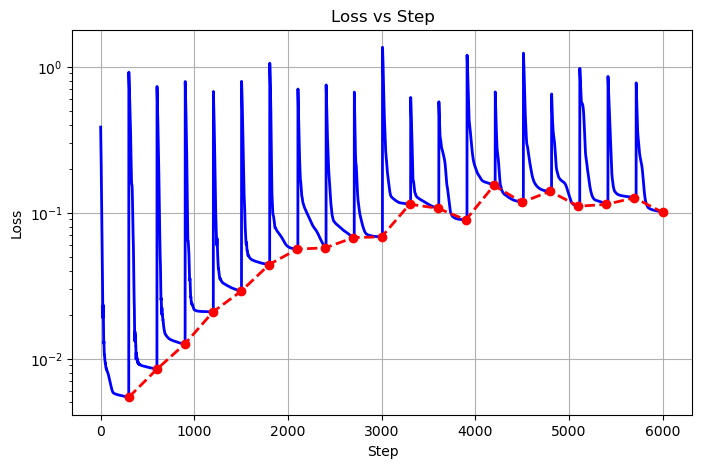

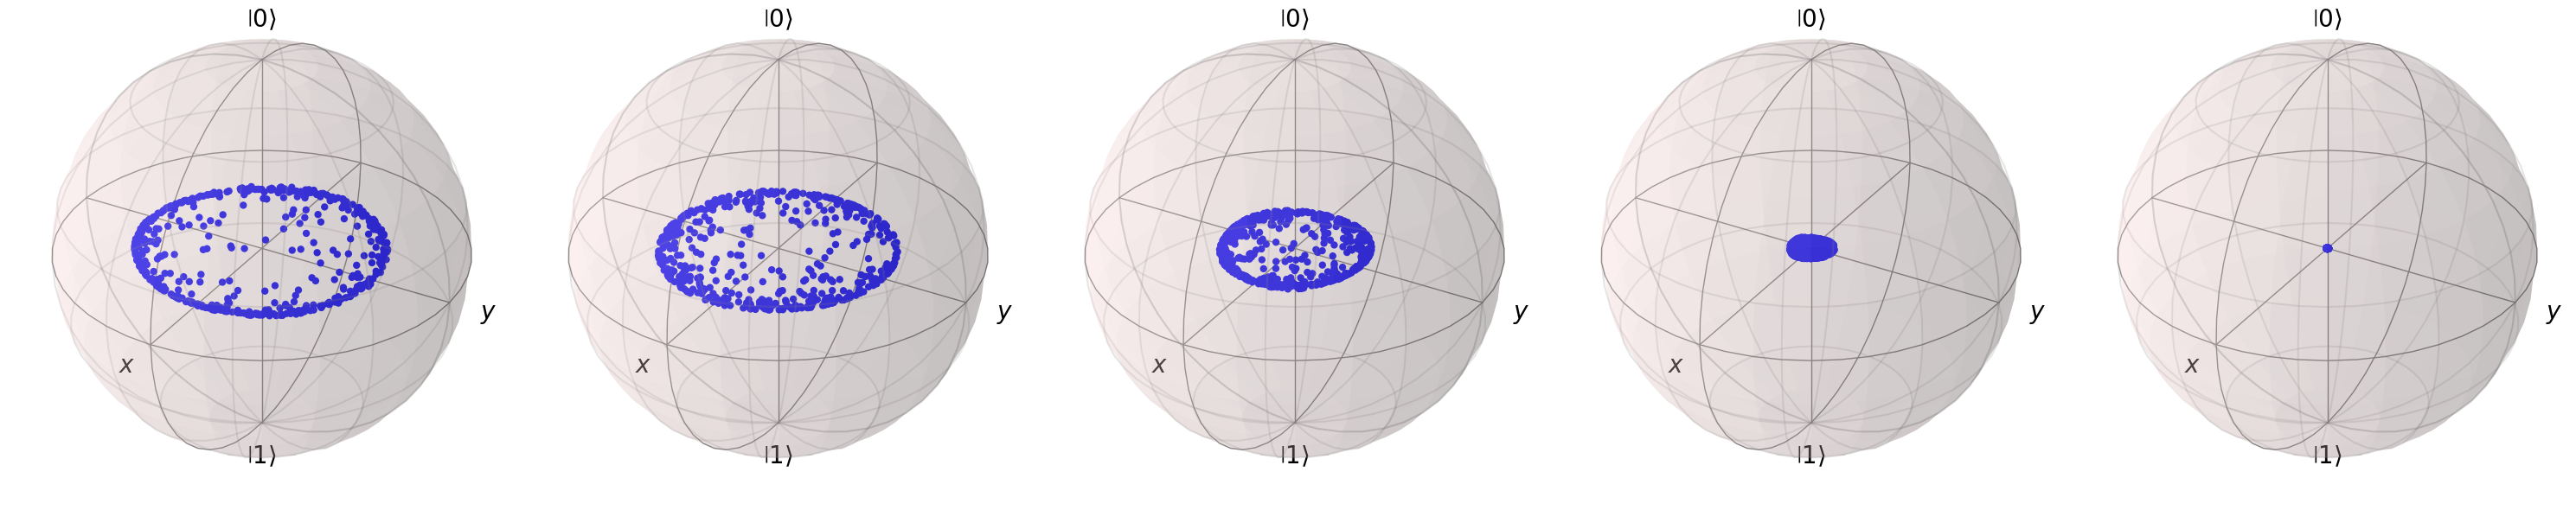

In [24]:
ut.plot_loss(loss_hist,best_loss_list, steps, logscale=True)
best_matrices=ut.time_ensemble_to_time_matrices(N,n,T,best_ensemble_probs,best_ensemble)

ut.plot_diffusion_mix(best_matrices,'b',N)

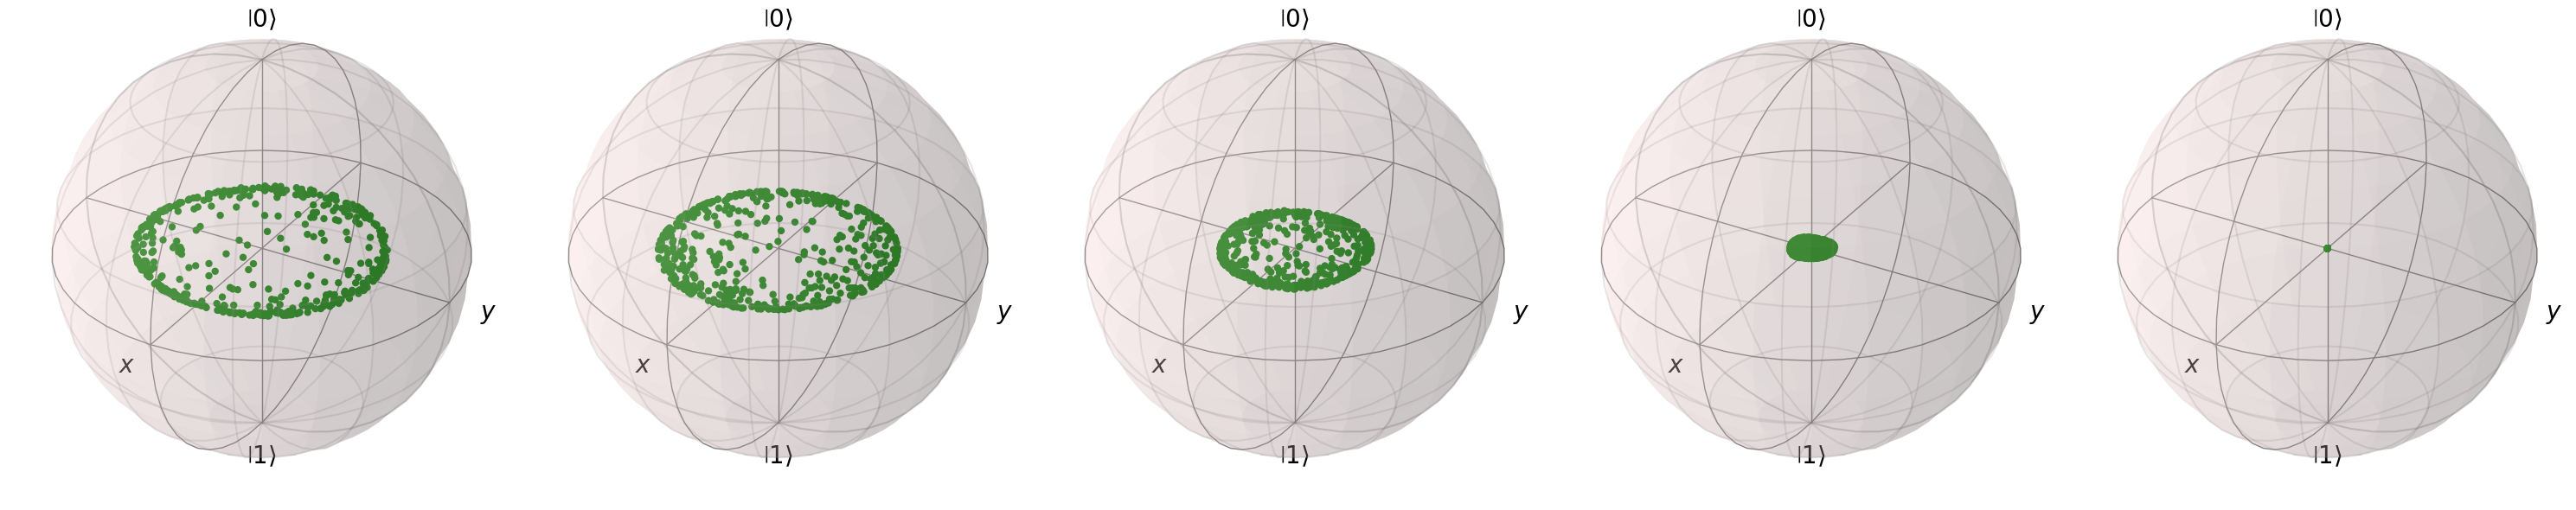

In [32]:
probs_noise, ensemble_noise=ut.generate_maximally_mixed_ensemble(N,n)

time_ensemble_test_gen=torch.zeros([Class*N, 2**n,2**n, T+1],dtype=torch.complex128)
time_probs_test_gen=torch.zeros([Class*N,2**n, T+1],dtype=torch.float64)
for i in range(Class):
    time_probs_test_gen[i*N:(i+1)*N,:,:],time_ensemble_test_gen[i*N:(i+1)*N,:,:,:]=quantum_denoising.backward_test(N,best_params,ensemble_noise,probs_noise,0)

test_matrices=ut.time_ensemble_to_time_matrices(N,n,T,time_probs_test_gen,time_ensemble_test_gen)
ut.plot_diffusion_mix(test_matrices,'g',N)